Connected!


C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_22276\1108435471.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(q1, cnx)


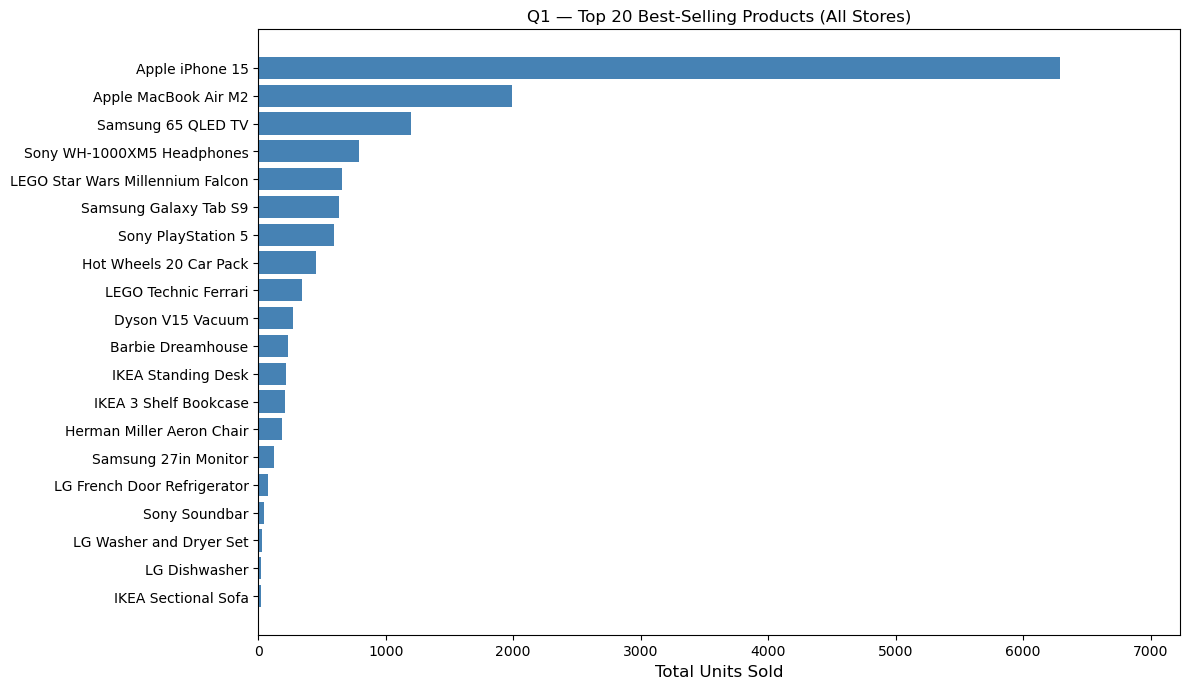

C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_22276\1108435471.py:47: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(q2, cnx)


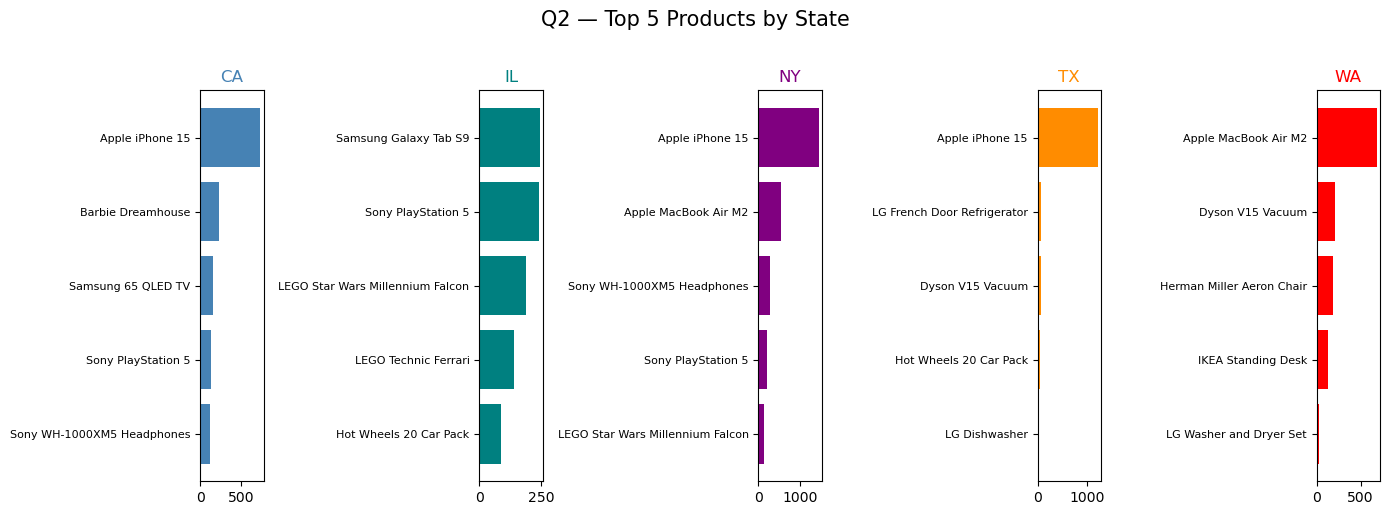

C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_22276\1108435471.py:74: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql(q3, cnx)


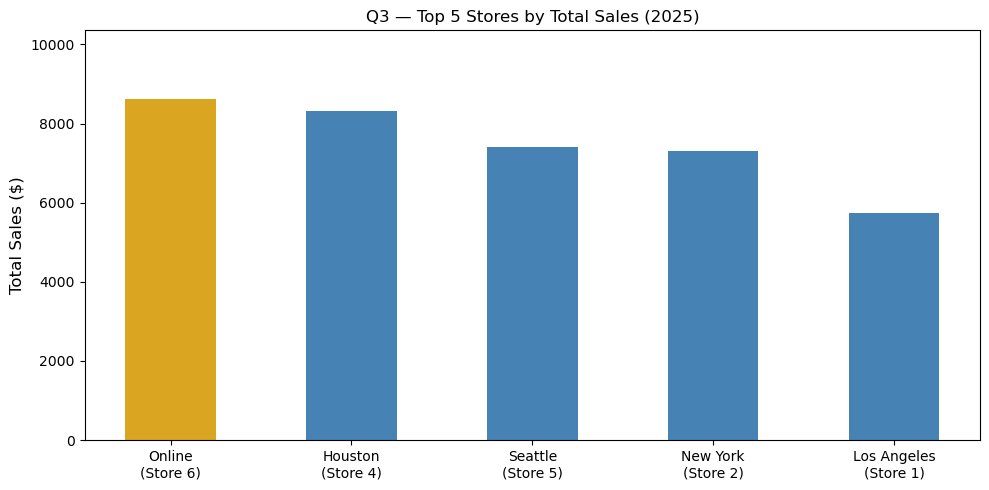

C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_22276\1108435471.py:106: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df4 = pd.read_sql(q4, cnx)


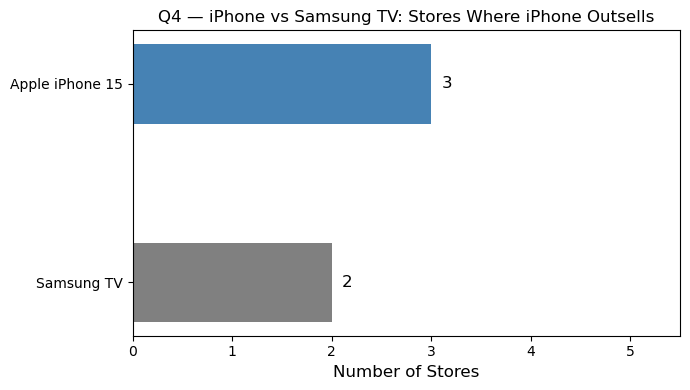

C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_22276\1108435471.py:136: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df5 = pd.read_sql(q5, cnx)


Q4 done — iPhone outsells Samsung TV in 3 out of 5 stores



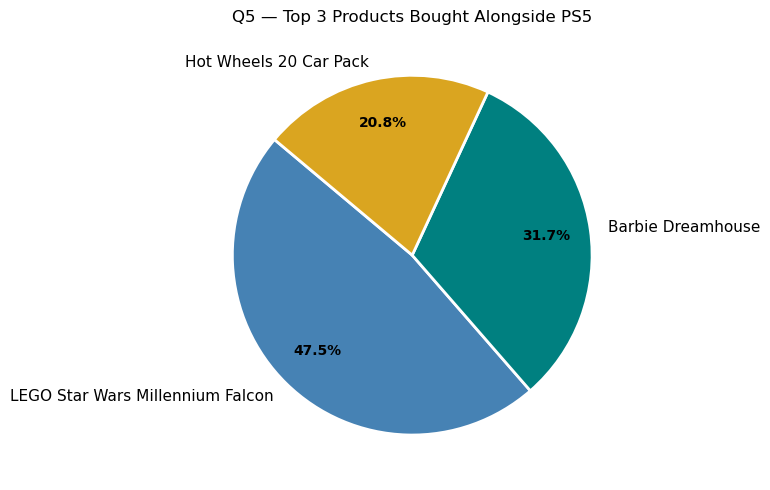

C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_22276\1108435471.py:175: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df6 = pd.read_sql(q6, cnx)


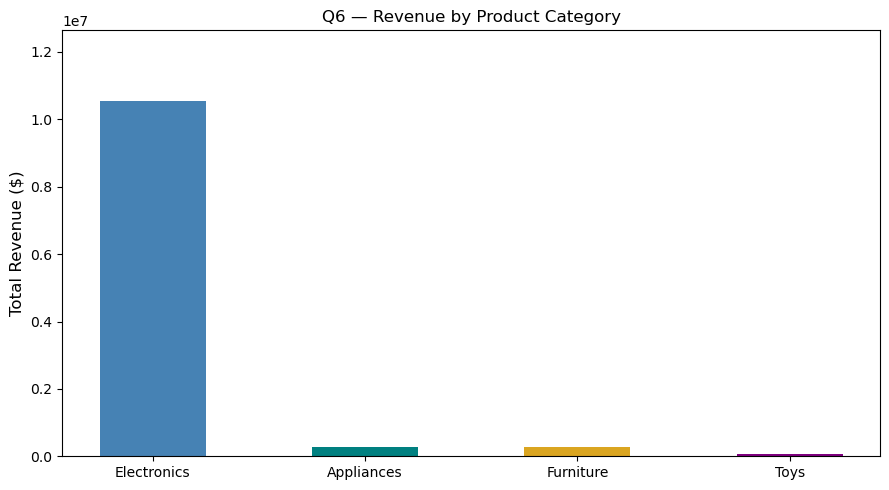

C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_22276\1108435471.py:197: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df7 = pd.read_sql(q7, cnx)


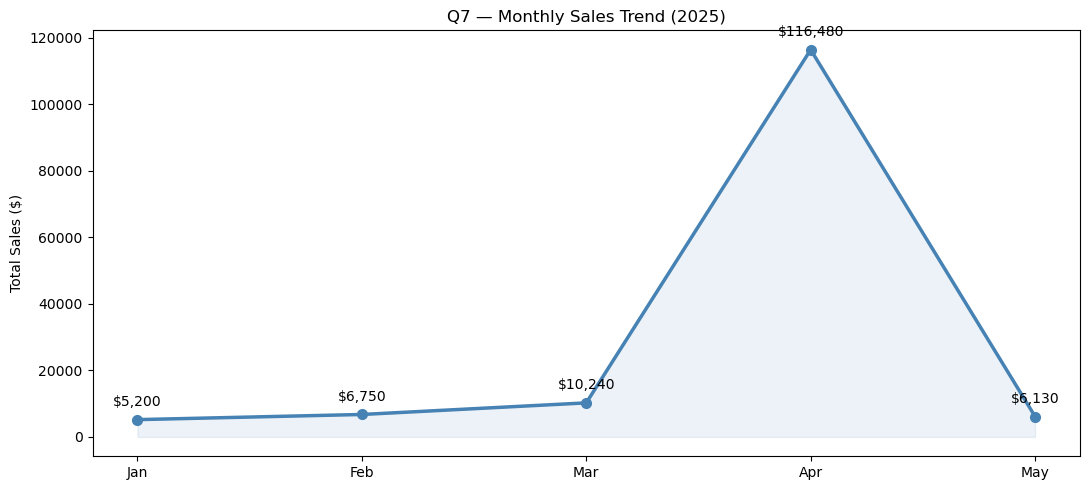

C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_22276\1108435471.py:219: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df8 = pd.read_sql(q8, cnx)


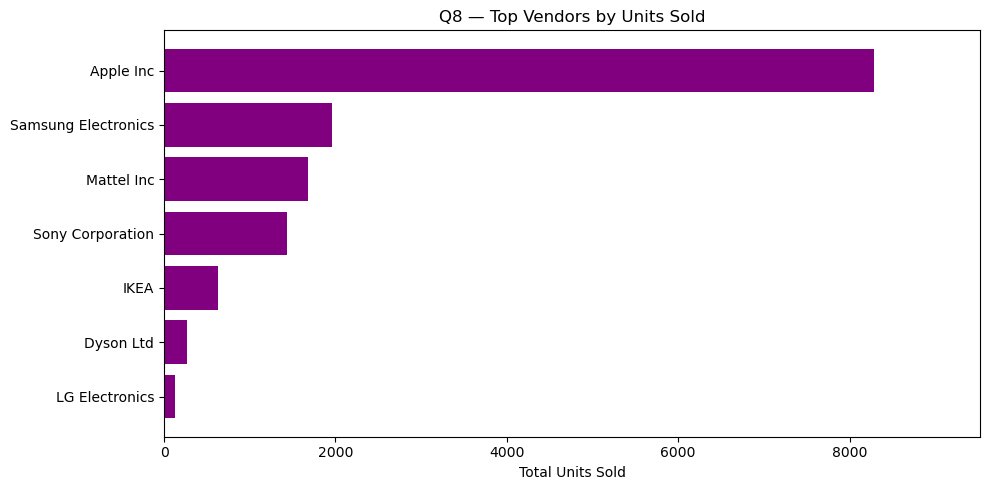

C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_22276\1108435471.py:241: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df9 = pd.read_sql(q9, cnx)


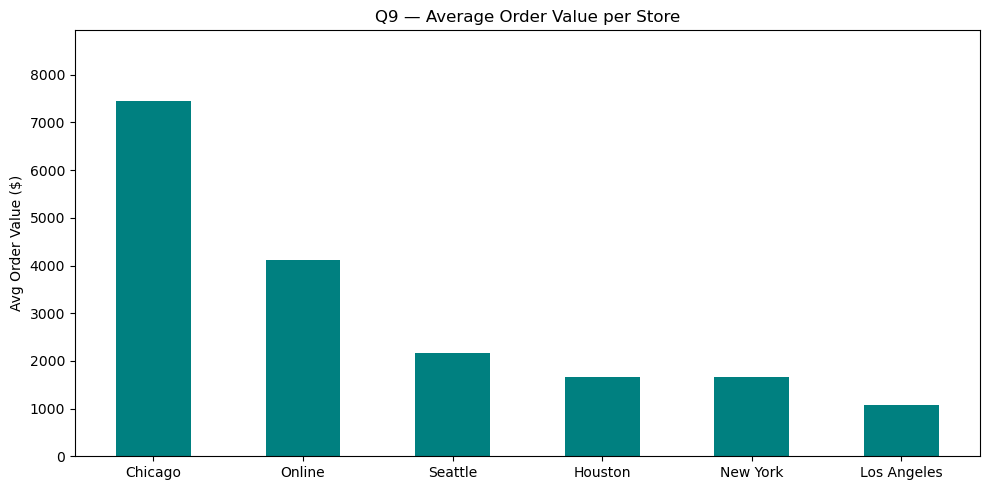

----------------------------------------
All 9 queries are complete.


In [5]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

cnx = mysql.connector.connect(
    user='root',
    password='',
    host='localhost',
    port=3306,
    database='final_project_2'
)

plt.rcParams['figure.figsize'] = (10, 4)
print("Connected!")


# REQUIRED QUERIES (1–5)

q1 = """
SELECT p.name, SUM(oi.quantity) AS total_sold
FROM order_item oi
JOIN product p ON oi.productID = p.productID
GROUP BY oi.productID
ORDER BY total_sold DESC
LIMIT 20
"""
df1 = pd.read_sql(q1, cnx)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(df1['name'][::-1], df1['total_sold'][::-1], color='steelblue')
ax.set_xlabel('Total Units Sold', fontsize=12)
ax.set_title('Q1 — Top 20 Best-Selling Products (All Stores)')
ax.set_xlim(0, df1['total_sold'].max() * 1.15)
plt.tight_layout()
plt.show()


q2 = """
SELECT bm.state, p.name, SUM(oi.quantity) AS total_sold
FROM orders o
JOIN order_item oi ON o.orderID = oi.orderID
JOIN product p ON oi.productID = p.productID
JOIN BM bm ON o.storeID = bm.storeID
GROUP BY bm.state, p.productID
ORDER BY bm.state, total_sold DESC
"""
df2 = pd.read_sql(q2, cnx)
df2_top = df2.groupby('state').head(5).reset_index(drop=True)
states = sorted(df2_top['state'].unique())
colors = ['steelblue', 'teal', 'purple', 'darkorange', 'red']
fig, axes = plt.subplots(1, len(states), figsize=(14, 5))
for i, state in enumerate(states):
    data = df2_top[df2_top['state'] == state]
    axes[i].barh(data['name'][::-1], data['total_sold'][::-1], color=colors[i])
    axes[i].set_title(state, color=colors[i])
    axes[i].tick_params(axis='y', labelsize=8)
    fig.suptitle('Q2 — Top 5 Products by State', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


q3 = """
SELECT o.storeID,
       COALESCE(bm.city, 'Online') AS store_name,
       SUM(op.total) AS total_sales
FROM orders o
JOIN order_payment op ON o.orderID = op.orderID
LEFT JOIN BM bm ON o.storeID = bm.storeID
WHERE YEAR(o.orderDate) = 2025
GROUP BY o.storeID
ORDER BY total_sales DESC
LIMIT 5
"""
df3 = pd.read_sql(q3, cnx)
df3['label'] = df3['store_name'] + '\n(Store ' + df3['storeID'].astype(str) + ')'

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['goldenrod'] + ['steelblue'] * (len(df3) - 1)
bars = ax.bar(df3['label'], df3['total_sales'], color=bar_colors, width=0.5)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.set_title('Q3 — Top 5 Stores by Total Sales (2025)')
ax.set_ylim(0, df3['total_sales'].max() * 1.2)
plt.tight_layout()
plt.show()


q4 = """
SELECT COUNT(DISTINCT o.storeID) AS stores_iphone_outsells_tv
FROM orders o
JOIN order_item oi ON o.orderID = oi.orderID
WHERE oi.productID = 6
AND o.storeID IN (
    SELECT o2.storeID
    FROM orders o2
    JOIN order_item oi2 ON o2.orderID = oi2.orderID
    WHERE oi2.productID = 1
    GROUP BY o2.storeID
    HAVING SUM(oi2.quantity) < (
        SELECT SUM(oi3.quantity)
        FROM orders o3
        JOIN order_item oi3 ON o3.orderID = oi3.orderID
        WHERE oi3.productID = 6 AND o3.storeID = o2.storeID
    )
)
"""
df4 = pd.read_sql(q4, cnx)
result = df4['stores_iphone_outsells_tv'].values[0]
total_stores = 5

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(['Samsung TV', 'Apple iPhone 15'],
        [total_stores - result, result],
        color=['gray', 'steelblue'], height=0.4)
ax.set_xlabel('Number of Stores', fontsize=12)
ax.set_title('Q4 — iPhone vs Samsung TV: Stores Where iPhone Outsells')
ax.set_xlim(0, total_stores + 0.5)
for i, v in enumerate([total_stores - result, result]):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=12)
plt.tight_layout()
plt.show()
print(f"Q4 done — iPhone outsells Samsung TV in {result} out of {total_stores} stores\n")


q5 = """
SELECT p.name, SUM(oi.quantity) AS times_bought_together
FROM order_item oi
JOIN product p ON oi.productID = p.productID
WHERE oi.orderID IN (
    SELECT orderID FROM order_item WHERE productID = 5
)
AND oi.productID != 5
GROUP BY oi.productID
ORDER BY times_bought_together DESC
LIMIT 3
"""
df5 = pd.read_sql(q5, cnx)

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    df5['times_bought_together'],
    labels=df5['name'],
    autopct='%1.1f%%',
    colors=['steelblue', 'teal', 'goldenrod'],
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in texts: t.set_fontsize(11)
for t in autotexts: t.set_fontsize(10); t.set_fontweight('bold')
ax.set_title('Q5 — Top 3 Products Bought Alongside PS5')
plt.tight_layout()
plt.show()


# ADDITIONAL QUERIES (6–9)

q6 = """
SELECT
    CASE
        WHEN e.productID IS NOT NULL THEN 'Electronics'
        WHEN a.productID IS NOT NULL THEN 'Appliances'
        WHEN t.productID IS NOT NULL THEN 'Toys'
        WHEN f.productID IS NOT NULL THEN 'Furniture'
    END AS category,
    ROUND(SUM(oi.quantity * p.price)) AS total_revenue
FROM order_item oi
JOIN product p ON oi.productID = p.productID
LEFT JOIN electronics e ON p.productID = e.productID
LEFT JOIN appliances a ON p.productID = a.productID
LEFT JOIN toys t ON p.productID = t.productID
LEFT JOIN furniture f ON p.productID = f.productID
GROUP BY category
ORDER BY total_revenue DESC
"""
df6 = pd.read_sql(q6, cnx)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['steelblue', 'teal', 'goldenrod', 'purple']
bars = ax.bar(df6['category'], df6['total_revenue'], color=bar_colors, width=0.5)
ax.set_ylabel('Total Revenue ($)', fontsize=12)
ax.set_title('Q6 — Revenue by Product Category')
ax.set_ylim(0, df6['total_revenue'].max() * 1.2)
plt.tight_layout()
plt.show()


q7 = """
SELECT
    DATE_FORMAT(o.orderDate, '%b') AS month,
    MONTH(o.orderDate) AS month_num,
    ROUND(SUM(op.total)) AS monthly_sales
FROM orders o
JOIN order_payment op ON o.orderID = op.orderID
GROUP BY month_num, month
ORDER BY month_num
"""
df7 = pd.read_sql(q7, cnx)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df7['month'], df7['monthly_sales'], color='steelblue', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(df7['month'], df7['monthly_sales'], alpha=0.1, color='steelblue')
for i, row in df7.iterrows():
    ax.annotate(f"${row['monthly_sales']:,.0f}", (row['month'], row['monthly_sales']),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)
ax.set_title('Q7 — Monthly Sales Trend (2025)')
ax.set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()


q8 = """
SELECT v.name AS vendor, SUM(oi.quantity) AS total_units
FROM order_item oi
JOIN product p ON oi.productID = p.productID
JOIN vendors v ON p.vendorID = v.vendorID
GROUP BY v.vendorID
ORDER BY total_units DESC
"""
df8 = pd.read_sql(q8, cnx)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df8['vendor'][::-1], df8['total_units'][::-1], color='purple')
ax.set_xlabel('Total Units Sold')
ax.set_title('Q8 — Top Vendors by Units Sold')
ax.set_xlim(0, df8['total_units'].max() * 1.15)
plt.tight_layout()
plt.show()


q9 = """
SELECT
    COALESCE(bm.city, 'Online') AS store_name,
    ROUND(AVG(op.total), 2) AS avg_order_value,
    COUNT(o.orderID) AS num_orders
FROM orders o
JOIN order_payment op ON o.orderID = op.orderID
LEFT JOIN BM bm ON o.storeID = bm.storeID
GROUP BY o.storeID
ORDER BY avg_order_value DESC
"""
df9 = pd.read_sql(q9, cnx)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df9['store_name'], df9['avg_order_value'],
              color='teal', width=0.5)
ax.set_ylabel('Avg Order Value ($)')
ax.set_title('Q9 — Average Order Value per Store')
ax.set_ylim(0, df9['avg_order_value'].max() * 1.2)
plt.tight_layout()
plt.show()

print("-" * 40)
print("All 9 queries are complete.")


cnx.close()